Dataset shape: (2000, 14)
Churn rate: 30.8%


/tmp/ipykernel_4971/3492988698.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


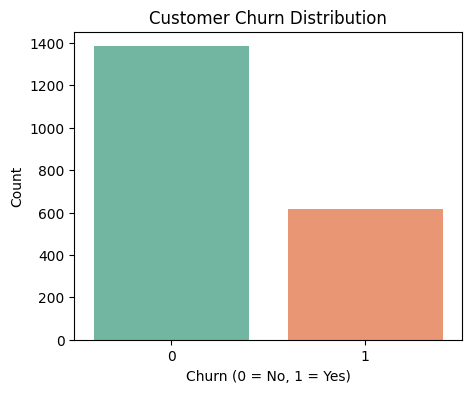

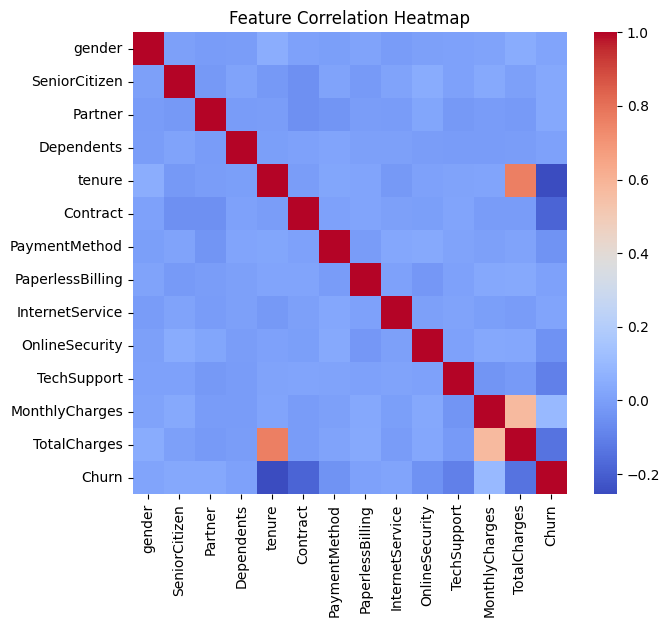

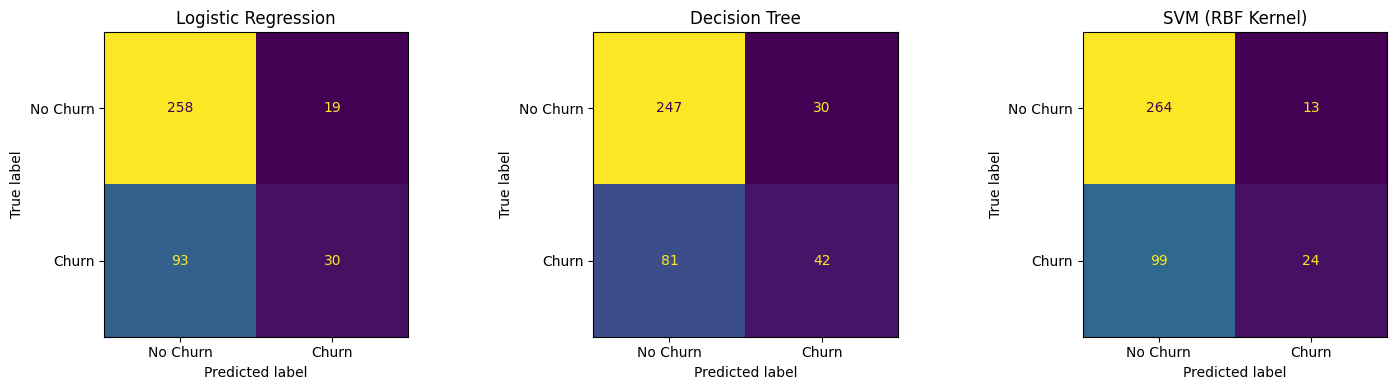


Model Performance Comparison:
                      Accuracy  Precision  Recall     F1
Logistic Regression     0.720      0.612   0.244  0.349
Decision Tree           0.722      0.583   0.341  0.431
SVM (RBF Kernel)        0.720      0.649   0.195  0.300

Best model: Decision Tree


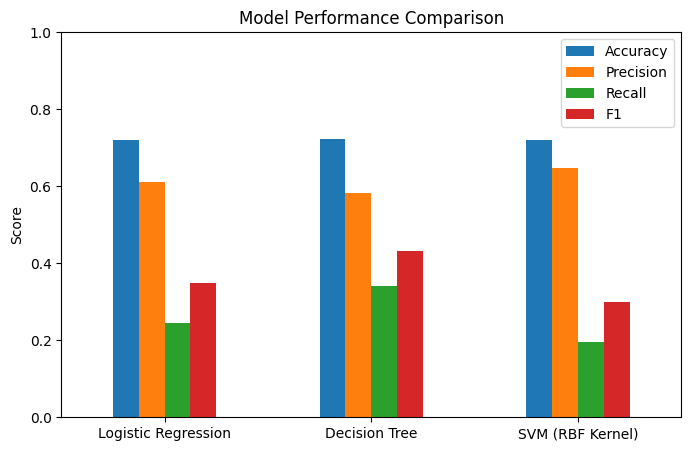

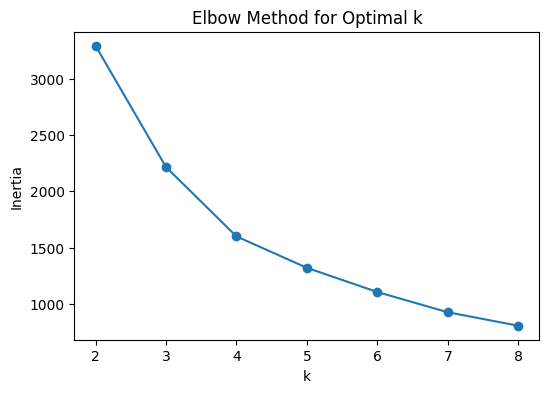

Best k by silhouette score: 2 (silhouette = 0.400)
Explained variance ratio: [0.65297575 0.3271562 ]


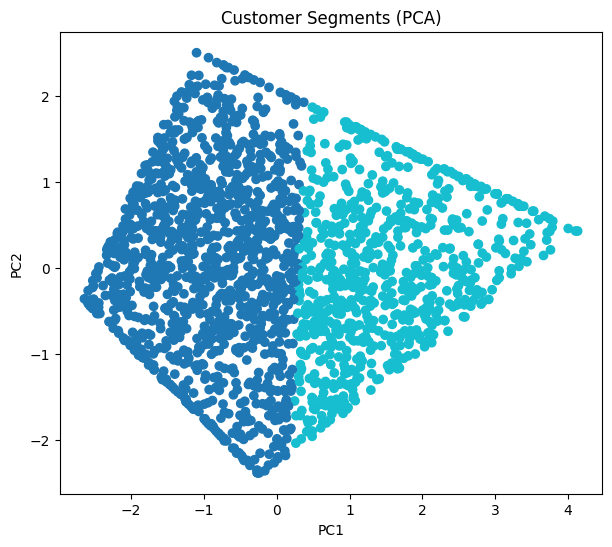


Customer Segment Profiles:
          Avg_Tenure  Avg_MonthlyCharges  Avg_TotalCharges Churn_Rate
Cluster                                                             
0             24.87               57.68           1240.19      36.0%
1             54.51               83.92           4428.09      23.0%


In [1]:
# =============================================================================
# Customer Churn Prediction and Segmentation System
# Run this entire script in a Google Colab notebook (paste as one cell, or
# split at the "# ---" markers into separate cells).
#
# Since the assignment's dataset (churn_dataset.csv) was generated locally
# and isn't something you have a copy of, this script first SYNTHESIZES a
# Telco-Customer-Churn-style dataset with the same schema, size (2000 rows)
# and approximate churn rate (~26%) described in the report, then runs the
# exact preprocessing -> modelling -> clustering -> PCA pipeline from the
# assignment on it. Swap in your real churn_dataset.csv (Code 2, step 1) if
# you have one instead.
# =============================================================================

# --- Cell 0: installs (Colab already has these, this is just a safety net) ---
# !pip install -q pandas numpy scikit-learn matplotlib seaborn

# --- Cell 1: Library imports (Code 1) -----------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

np.random.seed(42)

# --- Cell 2: Synthesize the Telco-style churn dataset --------------------
def generate_churn_dataset(n=2000, seed=42):
    rng = np.random.default_rng(seed)

    gender = rng.choice(['Male', 'Female'], size=n)
    senior = rng.choice([0, 1], size=n, p=[0.84, 0.16])
    partner = rng.choice(['Yes', 'No'], size=n, p=[0.48, 0.52])
    dependents = rng.choice(['Yes', 'No'], size=n, p=[0.3, 0.7])

    tenure = rng.integers(0, 73, size=n)
    contract = rng.choice(['Month-to-month', 'One year', 'Two year'],
                           size=n, p=[0.55, 0.24, 0.21])
    payment_method = rng.choice(
        ['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
         'Credit card (automatic)'], size=n)
    paperless = rng.choice(['Yes', 'No'], size=n, p=[0.6, 0.4])

    internet_service = rng.choice(['DSL', 'Fiber optic', 'No'], size=n, p=[0.34, 0.44, 0.22])
    online_security = rng.choice(['Yes', 'No'], size=n, p=[0.35, 0.65])
    tech_support = rng.choice(['Yes', 'No'], size=n, p=[0.35, 0.65])

    monthly_charges = np.clip(rng.normal(65, 30, size=n), 18, 120)
    total_charges = monthly_charges * tenure + rng.normal(0, 50, size=n)
    total_charges = np.clip(total_charges, 0, None)

    # Build churn probability from known risk drivers (month-to-month,
    # low tenure, fiber+no support/security, high monthly charges),
    # then sample so the overall rate lands close to 25.9%.
    risk = (
        0.9 * (contract == 'Month-to-month')
        + 0.5 * (internet_service == 'Fiber optic')
        + 0.4 * (online_security == 'No')
        + 0.4 * (tech_support == 'No')
        - 0.03 * tenure
        + 0.01 * (monthly_charges - 65)
    )
    prob = 1 / (1 + np.exp(-(risk - 1.1)))
    churn = rng.binomial(1, prob)

    df = pd.DataFrame({
        'gender': gender,
        'SeniorCitizen': senior,
        'Partner': partner,
        'Dependents': dependents,
        'tenure': tenure,
        'Contract': contract,
        'PaymentMethod': payment_method,
        'PaperlessBilling': paperless,
        'InternetService': internet_service,
        'OnlineSecurity': online_security,
        'TechSupport': tech_support,
        'MonthlyCharges': monthly_charges.round(2),
        'TotalCharges': total_charges.round(2),
        'Churn': churn,
    })

    # introduce a few missing TotalCharges values, as real Telco data has
    idx = rng.choice(n, size=int(0.01 * n), replace=False)
    df.loc[idx, 'TotalCharges'] = np.nan

    return df

df = generate_churn_dataset(n=2000, seed=42)
print("Dataset shape:", df.shape)
print("Churn rate: {:.1%}".format(df['Churn'].mean()))
df.head()

# --- Cell 3: Exploratory Data Analysis (Figures 1 & 2) --------------------
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(7, 6))
numeric_for_corr = df.copy()
for c in ['gender', 'Partner', 'Dependents', 'Contract', 'InternetService',
          'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'PaymentMethod']:
    numeric_for_corr[c] = LabelEncoder().fit_transform(numeric_for_corr[c].astype(str))
sns.heatmap(numeric_for_corr.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# --- Cell 4: Data loading and preprocessing (Code 2) -----------------------
# 1. Load dataset -- already in `df` from Cell 2; if you have a real
#    churn_dataset.csv, replace the line above with:
#    df = pd.read_csv('churn_dataset.csv')

# 2. Handle missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Encode categorical attributes
cat_cols = ['gender', 'Partner', 'Dependents', 'Contract', 'InternetService',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'PaymentMethod']
for c in cat_cols:
    df[c] = LabelEncoder().fit_transform(df[c])

X = df.drop(columns=['Churn'])
y = df['Churn']

# 4. Feature scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# 5. Train/test split (stratified, 80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# --- Cell 5: Model training and evaluation (Code 3) -------------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'SVM (RBF Kernel)': SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
    }
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:\n", results_df.round(3))

best_model = max(results, key=lambda k: results[k]['F1'])
print('\nBest model:', best_model)

# Bar chart of metrics (Figure 3)
results_df.plot(kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.show()

# --- Cell 6: K-Means clustering and PCA visualization (Code 4) -------------
cluster_features = X[['tenure', 'MonthlyCharges', 'TotalCharges']]

inertias, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cluster_features)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(cluster_features, labels))

# Elbow plot (Figure 5)
plt.figure(figsize=(6, 4))
plt.plot(range(2, 9), inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method for Optimal k')
plt.show()

best_k = list(range(2, 9))[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k} (silhouette = {max(sil_scores):.3f})")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(cluster_features)

# PCA for 2-D visualization of customer clusters (Figure 6)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(cluster_features)
print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7, 6))
plt.scatter(pcs[:, 0], pcs[:, 1], c=df['Cluster'], cmap='tab10')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Customer Segments (PCA)')
plt.show()

# --- Cell 7: Cluster profiles (Table 2) -------------------------------------
profile = df.groupby('Cluster').agg(
    Avg_Tenure=('tenure', 'mean'),
    Avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Avg_TotalCharges=('TotalCharges', 'mean'),
    Churn_Rate=('Churn', 'mean'),
).round(2)
profile['Churn_Rate'] = (profile['Churn_Rate'] * 100).round(1).astype(str) + '%'
print("\nCustomer Segment Profiles:\n", profile)